In [1]:
!git clone https://github.com/RDS-Rath/EEEM068_Group42.git
%cd EEEM068_Group42

Cloning into 'EEEM068_Group42'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 34 (delta 7), reused 29 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (34/34), 11.35 MiB | 16.68 MiB/s, done.
Resolving deltas: 100% (7/7), done.
/content/EEEM068_Group42


In [2]:
!git checkout Sivaraman_Udaiyappan_01

Branch 'Sivaraman_Udaiyappan_01' set up to track remote branch 'Sivaraman_Udaiyappan_01' from 'origin'.
Switched to a new branch 'Sivaraman_Udaiyappan_01'


In [3]:
!mkdir -p notebooks src data results report

In [4]:
!pip -q install diffusers transformers accelerate safetensors datasets torchmetrics pytorch-fid matplotlib pandas pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 52.7 MB/s eta 0:00:00


In [5]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
GPU: Tesla T4


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
!ls "/content/drive/MyDrive"

 aml_backup	    Sivaraman_Udaiyappan_AML_Project_Details
 AML_PPT.gslides    Sivaraman_Udaiyappan_Research_Project_Details
'Colab Notebooks'  'Toy Diffusion Model using Hugging Face Diffusers.gslides'
 Lab3


In [10]:
!find "/content/drive/MyDrive" -iname "img_align_celeba.zip"

/content/drive/MyDrive/Sivaraman_Udaiyappan_AML_Project_Details/img_align_celeba.zip


In [11]:
!mkdir -p /content/EEEM068_Group42/data/celeba_raw
!unzip -q "/content/drive/MyDrive/Sivaraman_Udaiyappan_AML_Project_Details/img_align_celeba.zip" -d /content/EEEM068_Group42/data/celeba_raw

In [12]:
from pathlib import Path

data_path = Path("/content/EEEM068_Group42/data/celeba_raw")
images = sorted([p for p in data_path.rglob("*") if p.suffix.lower() in [".jpg", ".jpeg", ".png"]])

print("Total images found:", len(images))
for p in images[:5]:
    print(p)

Total images found: 202599
/content/EEEM068_Group42/data/celeba_raw/img_align_celeba/000001.jpg
/content/EEEM068_Group42/data/celeba_raw/img_align_celeba/000002.jpg
/content/EEEM068_Group42/data/celeba_raw/img_align_celeba/000003.jpg
/content/EEEM068_Group42/data/celeba_raw/img_align_celeba/000004.jpg
/content/EEEM068_Group42/data/celeba_raw/img_align_celeba/000005.jpg


In [13]:
images_30k = images[:30000]

print("Using images:", len(images_30k))
print("First image:", images_30k[0])
print("Last image:", images_30k[-1])

Using images: 30000
First image: /content/EEEM068_Group42/data/celeba_raw/img_align_celeba/000001.jpg
Last image: /content/EEEM068_Group42/data/celeba_raw/img_align_celeba/030000.jpg


In [14]:
from pathlib import Path

train_dir = Path("/content/EEEM068_Group42/data/train")
test_dir = Path("/content/EEEM068_Group42/data/test")

train_dir.mkdir(parents=True, exist_ok=True)
test_dir.mkdir(parents=True, exist_ok=True)

print("Folders created")

Folders created


In [15]:
train_images = images_30k[:27000]
test_images = images_30k[27000:30000]

print("Train images:", len(train_images))
print("Test images:", len(test_images))

Train images: 27000
Test images: 3000


In [16]:
import shutil

for img in train_images:
    shutil.copy(img, train_dir / img.name)

for img in test_images:
    shutil.copy(img, test_dir / img.name)

print("Copy completed")

Copy completed


In [17]:
!ls /content/EEEM068_Group42/data/train | wc -l
!ls /content/EEEM068_Group42/data/test | wc -l

27000
3000


In [18]:
from diffusers import StableDiffusionPipeline
import torch

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

print("Model loaded successfully")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully


In [19]:
import os

output_dir = "/content/EEEM068_Group42/results/generated_faces"
os.makedirs(output_dir, exist_ok=True)

prompts = [
    "portrait photo of a human face",
    "realistic female face portrait",
    "realistic male face portrait",
    "young person face portrait",
    "studio headshot of a person"
]

num_images = 300

for i in range(num_images):
    prompt = prompts[i % len(prompts)]
    image = pipe(prompt).images[0]
    image.save(f"{output_dir}/gen_{i:03d}.png")

    if (i + 1) % 20 == 0:
        print(f"Generated {i+1}/{num_images}")

print("Finished generating 300 images")

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Generated 300/300
Finished generating 300 images


In [20]:
!ls /content/EEEM068_Group42/results/generated_faces | wc -l

300


In [21]:
import os
import random
import shutil
from pathlib import Path

random.seed(42)

test_dir = Path("/content/EEEM068_Group42/data/test")
test_sample_dir = Path("/content/EEEM068_Group42/data/test_sample")
test_sample_dir.mkdir(parents=True, exist_ok=True)

test_images = list(test_dir.glob("*"))
sample_test = random.sample(test_images, 300)

for img in sample_test:
    shutil.copy(img, test_sample_dir / img.name)

print("Test sample created:", len(list(test_sample_dir.glob('*'))))

Test sample created: 300


In [24]:
!python -m pytorch_fid \
/content/EEEM068_Group42/data/test_sample \
/content/EEEM068_Group42/results/generated_faces

100% 6/6 [00:01<00:00,  3.41it/s]
100% 6/6 [00:05<00:00,  1.20it/s]
FID:  168.60801059656615


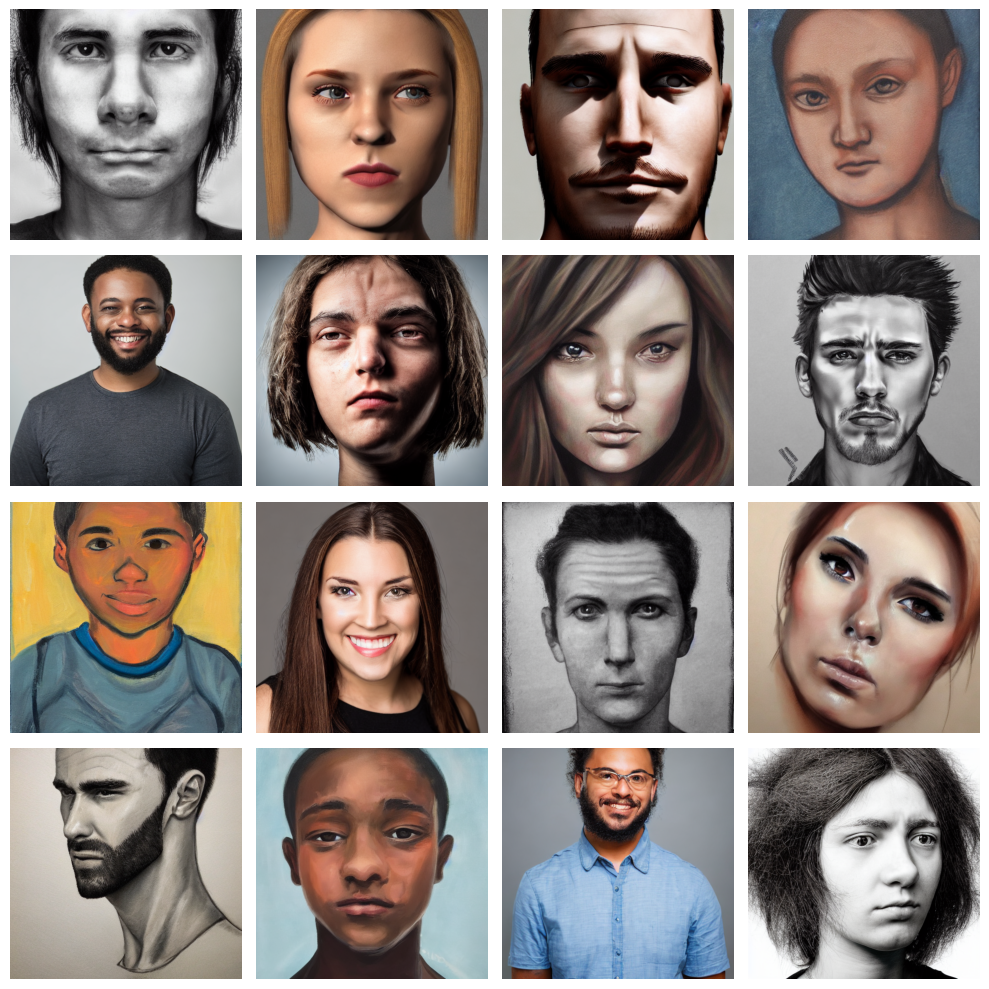

In [23]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

gen_dir = Path("/content/EEEM068_Group42/results/generated_faces")
sample_imgs = sorted(gen_dir.glob("*.png"))[:16]

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for ax, img_path in zip(axes.flatten(), sample_imgs):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.savefig("/content/EEEM068_Group42/results/generated_grid.png", bbox_inches="tight")
plt.show()

In [25]:
fid_score = 168.60801059656615
print("Final FID Score:", fid_score)

Final FID Score: 168.60801059656615


In [26]:
!ls /content/EEEM068_Group42/results

final_output.png  generated_grid.png  img_2.png  img_4.png
generated_faces   img_1.png	      img_3.png  img_5.png
